In [21]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report
import matplotlib.pyplot as plt

data=pd.read_csv("marks.csv")

data.head()

X=data.drop(columns='result',axis=1)
Y=data['result']


X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2
,stratify=Y,random_state=2)


print(Y.shape,X.shape,X_train.shape,X_test.shape,Y_train.shape,Y_test.shape)


model=LogisticRegression()
model.fit(X_train,Y_train)


input_data=(90,50)
input_data_as_numpy_array=np.asarray(input_data)
input_data_reshaped=input_data_as_numpy_array.reshape(1,-1)
prediction=model.predict(input_data_reshaped)
print(prediction)

if(prediction[0]==0):
   print("FAIL")
else:
   print("PASS")

input_data=(2,1)
input_data_as_numpy_array=np.asarray(input_data)
input_data_reshaped=input_data_as_numpy_array.reshape(1,-1)
prediction=model.predict(input_data_reshaped)
print(prediction)

if(prediction[0]==0):
   print("FAIL")
else:
   print("PASS")





(141,) (141, 2) (112, 2) (29, 2) (112,) (29,)
[1]
PASS
[0]
FAIL


C:\Users\lenovo 2020\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\lenovo 2020\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Accuracy on Training data 0.9285714285714286
Accuracy on Test data: 0.9655172413793104
Confusion Matrix:
[[12  1]
 [ 0 16]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        13
           1       0.94      1.00      0.97        16

    accuracy                           0.97        29
   macro avg       0.97      0.96      0.96        29
weighted avg       0.97      0.97      0.97        29



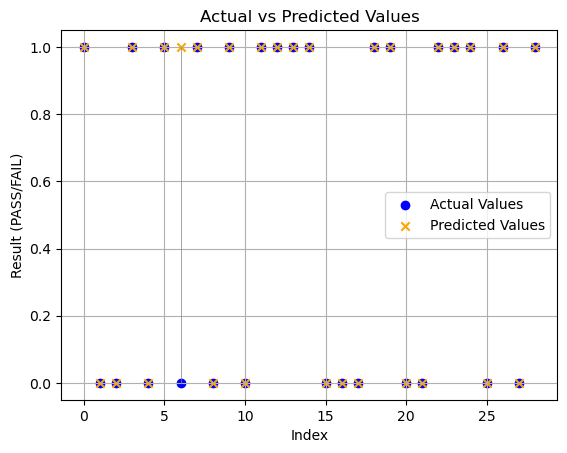

In [22]:
X_train_prediction=model.predict(X_train)
training_data_accuracy=accuracy_score(X_train_prediction,Y_train)

print("Accuracy on Training data",training_data_accuracy)


X_test_prediction=model.predict(X_test)
test_data_accuracy=accuracy_score(X_test_prediction,Y_test)

print("Accuracy on Test data:",test_data_accuracy)

# Confusion Matrix
conf_matrix = confusion_matrix(Y_test, X_test_prediction)
print("Confusion Matrix:")
print(conf_matrix)

# Classification Report
class_report = classification_report(Y_test, X_test_prediction)
print("Classification Report:")
print(class_report)


plt.scatter(range(len(Y_test)), Y_test, color='blue', label='Actual Values', marker='o')
plt.scatter(range(len(X_test_prediction)), X_test_prediction, color='orange', label='Predicted Values', marker='x')

# Connecting lines between Actual and Predicted values
for i in range(len(Y_test)):
    plt.plot([i, i], [Y_test.iloc[i], X_test_prediction[i]], color='gray', linewidth=0.5)

plt.title('Actual vs Predicted Values')
plt.xlabel('Index')
plt.ylabel('Result (PASS/FAIL)')
plt.legend()
plt.grid(True)
plt.show()